# PM2.5 Prediction Visualization

This notebook visualizes rolling prediction results against ground truth for 2019.

Run cells in order.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import cartopy.io.shapereader as shpreader
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

plt.rcParams['figure.dpi'] = 120

In [2]:
# Paths (modify if needed)
pred_path = '/shz/PM_re/experiments/pm25_earthformer/pm25_pred_2019_rolling.int16.dat'
gt_path = '/shz/data/pm25.zarr'
start_date = '2019-01-01'
end_date = '2019-12-31'
plot_date = '2019-01-06'

# Speed/quality tradeoff
map_stride = 1      # 1 = full resolution
metric_stride = 1   # 1 = full resolution

In [3]:
gt_ds = xr.open_zarr(gt_path)
gt = gt_ds['pm25'].sel(time=slice(start_date, end_date)).astype(np.float32)

t = gt.sizes['time']
h = gt.sizes['lat']
w = gt.sizes['lon']

if pred_path.endswith('.zarr'):
    pred_ds = xr.open_zarr(pred_path)
    pred = pred_ds['pm25_pred'].sel(time=slice(start_date, end_date)).astype(np.float32)
else:
    pred_dtype = np.int16 if pred_path.endswith('.int16.dat') else np.float32
    arr = np.memmap(pred_path, mode='r', dtype=pred_dtype, shape=(t, h, w))
    pred = xr.DataArray(arr, dims=('time', 'lat', 'lon'), coords={'time': gt.time, 'lat': gt.lat, 'lon': gt.lon}).astype(np.float32)

# Detect likely unfilled days in rolling .dat output (all pixels are zero).
day_nonzero_frac = ((pred != 0).mean(dim=('lat', 'lon'))).astype(np.float32)
valid_day_mask = day_nonzero_frac > 1e-6
valid_days = pd.to_datetime(gt.time.values[valid_day_mask.values])

print('GT shape:', gt.shape)
print('Pred shape:', pred.shape)
print(f'Valid predicted days (non-zero): {int(valid_day_mask.sum().values)} / {t}')
if len(valid_days) > 0:
    print('Predicted date coverage:', valid_days[0].date(), '->', valid_days[-1].date())
else:
    print('No non-zero prediction days detected. This usually means rolling run was interrupted before write-back.')

GT shape: (365, 768, 1280)
Pred shape: (365, 768, 1280)
Valid predicted days (non-zero): 16 / 365
Predicted date coverage: 2019-01-01 -> 2019-01-16


In [4]:
# Rebuild derived variables in case a prep cell was removed.
if 'valid_day_mask' not in locals():
    day_nonzero_frac = ((pred != 0).mean(dim=('lat', 'lon'))).astype(np.float32)
    valid_day_mask = day_nonzero_frac > 1e-6
    valid_days = pd.to_datetime(gt.time.values[valid_day_mask.values])

has_valid_pred = bool(valid_day_mask.any().values)
gt_metric_valid = gt.where(valid_day_mask, drop=True).isel(lat=slice(None, None, metric_stride), lon=slice(None, None, metric_stride))
pred_metric_valid = pred.where(valid_day_mask, drop=True).isel(lat=slice(None, None, metric_stride), lon=slice(None, None, metric_stride))
abs_err = np.abs(pred_metric_valid - gt_metric_valid)

if has_valid_pred:
    mae = float(abs_err.mean().values)
    rmse = float(np.sqrt(((pred_metric_valid - gt_metric_valid) ** 2).mean().values))
    bias = float((pred_metric_valid - gt_metric_valid).mean().values)
else:
    mae = float('nan')
    rmse = float('nan')
    bias = float('nan')

if not has_valid_pred:
    print('Skip map plot: no valid predicted days in current prediction file.')
else:
    out_dir = Path('/shz/PM_re/img')
    out_dir.mkdir(parents=True, exist_ok=True)

    gt_positive_valid = gt_metric_valid.where(gt_metric_valid > 0)
    pred_positive_valid = pred_metric_valid.where(gt_metric_valid > 0)
    err_positive_valid = (pred_metric_valid - gt_metric_valid).where(gt_metric_valid > 0)

    joint_vals = np.concatenate([
        gt_positive_valid.values.reshape(-1),
        pred_positive_valid.values.reshape(-1),
    ])
    joint_vals = joint_vals[np.isfinite(joint_vals)]
    if joint_vals.size == 0:
        joint_vals = np.concatenate([gt_metric_valid.values.reshape(-1), pred_metric_valid.values.reshape(-1)])
        joint_vals = joint_vals[np.isfinite(joint_vals)]

    if joint_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin = float(np.nanpercentile(joint_vals, 1))
        vmax = float(np.nanpercentile(joint_vals, 99))

    err_vals = np.abs(err_positive_valid.values.reshape(-1))
    err_vals = err_vals[np.isfinite(err_vals)]
    if err_vals.size == 0:
        err_vals = np.abs((pred_metric_valid - gt_metric_valid).values.reshape(-1))
        err_vals = err_vals[np.isfinite(err_vals)]
    emax = float(np.nanpercentile(err_vals, 99)) if err_vals.size > 0 else 1.0

    valid_plot_days = [pd.Timestamp(day) for day in valid_days]
    lon_vals = gt.lon.values[::map_stride]
    lat_vals = gt.lat.values[::map_stride]
    lon_min = float(lon_vals.min())
    lon_max = float(lon_vals.max())
    lat_min = 16.6
    lat_max = 55
    data_extent = [lon_min, lon_max, lat_min, lat_max]
    main_extent = [80, 135, 17, 50]
    zoom_extent = [105, 125, 0, 25]
    lon_zoom_mask = (lon_vals >= zoom_extent[0]) & (lon_vals <= zoom_extent[1])
    lat_zoom_mask = (lat_vals >= zoom_extent[2]) & (lat_vals <= zoom_extent[3])
    lon_zoom_idx = np.where(lon_zoom_mask)[0]
    lat_zoom_idx = np.where(lat_zoom_mask)[0]

    if HAS_CARTOPY:
        proj = ccrs.LambertConformal(central_longitude=117, central_latitude=26, standard_parallels=(30, 60))
        reader = shpreader.Reader('/shz/shape/bou2_4l.shp')
        country_borders = cfeature.ShapelyFeature(reader.geometries(),
                                           crs = ccrs.PlateCarree(),
                                           edgecolor = 'face',
                                           facecolor = 'None'
                                          )
    else:
        print('Cartopy unavailable; falling back to plain imshow output.')

    from concurrent.futures import ThreadPoolExecutor

    def render_one_day(plot_day):
        gt_day = gt.sel(time=plot_day).isel(lat=slice(None, None, map_stride), lon=slice(None, None, map_stride))
        pred_day = pred.sel(time=plot_day).isel(lat=slice(None, None, map_stride), lon=slice(None, None, map_stride))
        gt_mask = gt_day.values > 0
        gt_day_plot = np.where(gt_mask, gt_day.values, np.nan)
        pred_day_plot = np.where(gt_mask, pred_day.values, np.nan)
        ae_day_plot = np.where(gt_mask, np.abs(pred_day.values - gt_day.values), np.nan)

        day_zero_ratio = float((pred_day.values == 0).mean())
        print(f'{plot_day.date()} pred zero_ratio={day_zero_ratio:.6f}')

        save_path = out_dir / f'{plot_day:%Y-%m-%d}.jpg'

        if HAS_CARTOPY:
            fig = plt.figure(figsize=(18, 6), dpi=350)
            axes = [fig.add_subplot(1, 3, idx + 1, projection=proj) for idx in range(3)]

            for ax in axes:
                ax.set_extent(main_extent, crs=ccrs.PlateCarree())
                ax.add_feature(country_borders, edgecolor='black', linewidth=0.6)
                # ax.coastlines(resolution='10m', linewidth=0.4, color='black')

            im0 = axes[0].imshow(
                gt_day_plot,
                transform=ccrs.PlateCarree(),
                extent=data_extent,
                cmap='coolwarm',
                origin='upper',
                vmin=vmin,
                vmax=vmax,
            )
            axes[0].set_title(f'Ground Truth {plot_day.date()}')
            axes[0].gridlines(
                xlocs=np.arange(70, 141, 10),
                ylocs=np.arange(10, 61, 10),
                draw_labels=True,
                x_inline=False,
                y_inline=False,
                linewidth=0.5,
                linestyle='--',
                color='gray',
                rotate_labels=False,
            )

            im1 = axes[1].imshow(
                pred_day_plot,
                transform=ccrs.PlateCarree(),
                extent=data_extent,
                cmap='coolwarm',
                origin='upper',
                vmin=vmin,
                vmax=vmax,
            )
            axes[1].set_title(f'Prediction {plot_day.date()}')
            axes[1].gridlines(
                xlocs=np.arange(70, 141, 10),
                ylocs=np.arange(10, 61, 10),
                draw_labels=False,
                x_inline=False,
                y_inline=False,
                linewidth=0.5,
                linestyle='--',
                color='gray',
                rotate_labels=False,
            )

            im2 = axes[2].imshow(
                ae_day_plot,
                transform=ccrs.PlateCarree(),
                extent=data_extent,
                cmap='magma',
                origin='upper',
                vmin=0,
                vmax=emax,
            )
            axes[2].set_title(f'Absolute Error {plot_day.date()}')
            axes[2].gridlines(
                xlocs=np.arange(70, 141, 10),
                ylocs=np.arange(10, 61, 10),
                draw_labels=False,
                x_inline=False,
                y_inline=False,
                linewidth=0.5,
                linestyle='--',
                color='gray',
                rotate_labels=False,
            )

            fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label=r'($\mu g\ m^{-3}$)')
            fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label=r'($\mu g\ m^{-3}$)')
            fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='Absolute error')
            fig.suptitle(f'PM2.5 Comparison | MAE={mae:.3f}, RMSE={rmse:.3f}, BIAS={bias:.3f}')
            fig.savefig(save_path, bbox_inches='tight')
            plt.close(fig)
        else:
            fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

            im0 = axes[0].imshow(gt_day_plot, cmap='coolwarm', vmin=vmin, vmax=vmax, origin='upper')
            axes[0].set_title(f'Ground Truth {plot_day.date()}')
            axes[0].axis('off')
            plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

            im1 = axes[1].imshow(pred_day_plot, cmap='coolwarm', vmin=vmin, vmax=vmax, origin='upper')
            axes[1].set_title(f'Prediction {plot_day.date()}')
            axes[1].axis('off')
            plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

            im2 = axes[2].imshow(ae_day_plot, cmap='magma', vmin=0, vmax=emax, origin='upper')
            axes[2].set_title(f'Absolute Error {plot_day.date()}')
            axes[2].axis('off')
            plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

            fig.suptitle(f'PM2.5 Comparison | MAE={mae:.3f}, RMSE={rmse:.3f}, BIAS={bias:.3f}')
            fig.savefig(save_path, bbox_inches='tight')
            plt.close(fig)

        print(f'Saved {save_path}')

    with ThreadPoolExecutor(max_workers=min(8, os.cpu_count() or 1)) as executor:
        list(executor.map(render_one_day, valid_plot_days))

2019-01-08 pred zero_ratio=0.000000
2019-01-02 pred zero_ratio=0.000000
2019-01-07 pred zero_ratio=0.000000
2019-01-06 pred zero_ratio=0.000000
2019-01-03 pred zero_ratio=0.000000
2019-01-04 pred zero_ratio=0.000000
2019-01-01 pred zero_ratio=0.000000
2019-01-05 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-08.jpg
2019-01-09 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-02.jpg
2019-01-10 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-03.jpg
2019-01-11 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-06.jpg
2019-01-12 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-01.jpg
2019-01-13 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-07.jpg
2019-01-14 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-05.jpg
2019-01-15 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-04.jpg
2019-01-16 pred zero_ratio=0.000000
Saved /shz/PM_re/img/2019-01-09.jpg
Saved /shz/PM_re/img/2019-01-10.jpg
Saved /shz/PM_re/img/2019-01-11.jpg
Saved /shz/PM_re/img/2019-01

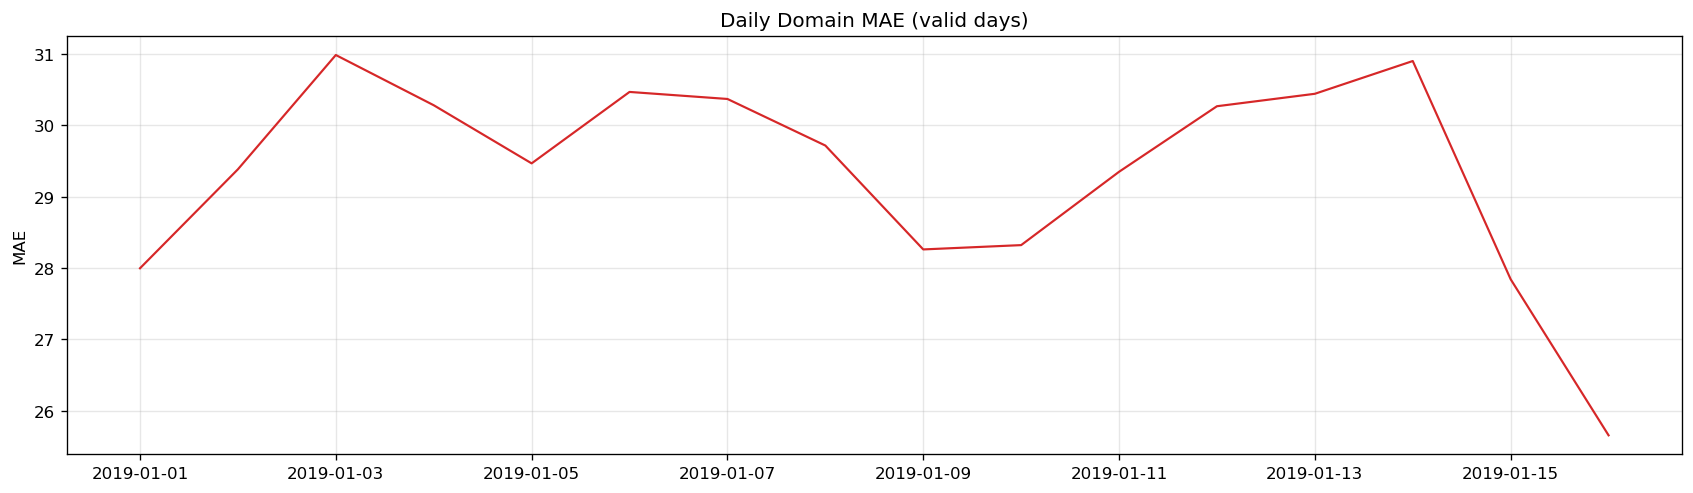

In [5]:
# Domain daily MAE curve (valid predicted days only)
if not has_valid_pred:
    print('Skip daily MAE plot: no valid predicted days.')
else:
    daily_mae = abs_err.mean(dim=('lat', 'lon'))
    daily_time = pd.to_datetime(daily_mae.time.values)

    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
    ax.plot(daily_time, daily_mae.values, color='tab:red', linewidth=1.3)
    ax.set_title('Daily Domain MAE (valid days)')
    ax.set_ylabel('MAE')
    ax.grid(alpha=0.3)
    plt.show()